In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

file_name = "clean_df_Laptop.csv"
df = pd.read_csv(file_name, header=0, index_col=0)
df.head()

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Screen_Size_in,Weight_lb,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,35.56,0.551724,8,256,1.60,978,14.000000,3.52800,Low,False,True
1,Dell,3,1,1,3,39.62,0.689655,4,256,2.20,634,15.598425,4.85100,Low,True,False
2,Dell,3,1,1,7,39.62,0.931034,8,256,2.20,946,15.598425,4.85100,Low,True,False
3,Dell,4,2,1,5,33.78,0.551724,8,128,1.22,1244,13.299213,2.69010,Low,False,True
4,HP,4,2,1,7,39.62,0.620690,8,256,1.91,837,15.598425,4.21155,Low,True,False


In [3]:
# Continuous Numerical Variables

# correlation between selected columns
df[['CPU_frequency','Screen_Size_in','Weight_lb']].corr()

,CPU_frequency,Screen_Size_in,Weight_lb
CPU_frequency,1.000000,-0.000955,0.066522
Screen_Size_in,-0.000955,1.000000,0.797605
Weight_lb,0.066522,0.797605,1.000000


(0.0, 3974.15)

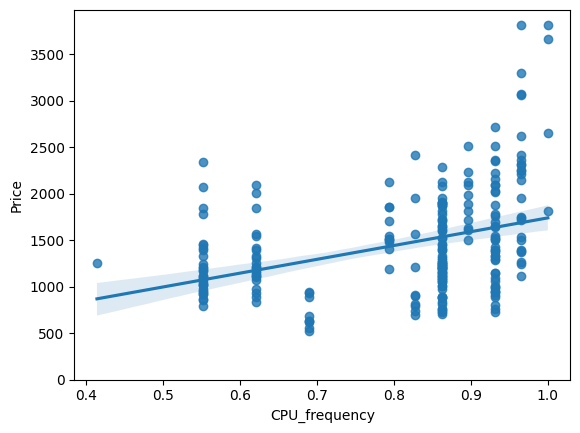

In [4]:
# Continuous Numerical variables with scatterplot
sns.regplot(x='CPU_frequency',y='Price', data=df)
plt.ylim(0,)


(0.0, 3974.15)

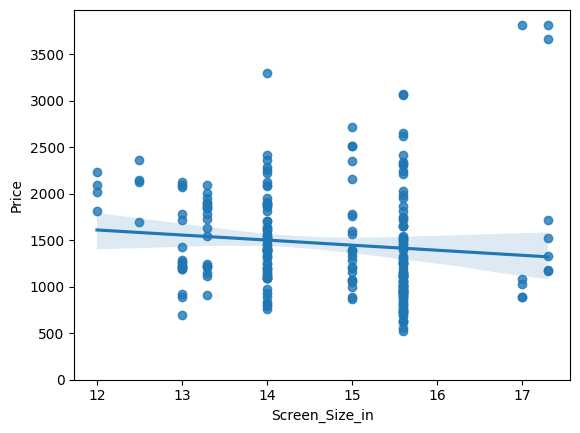

In [5]:
# Continuous Numerical variables with scatterplot
sns.regplot(x='Screen_Size_in',y='Price', data=df)
plt.ylim(0,)


(0.0, 3974.15)

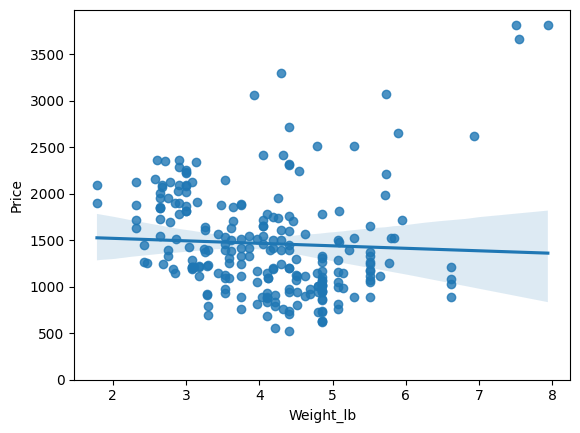

In [6]:
# Continuous Numerical variables with scatterplot
sns.regplot(x='Weight_lb',y='Price', data=df)
plt.ylim(0,)


In [7]:
# CPU_frequency has a 36.6% positive correlation with the price of the laptops. Ther others have week correlation with price.
for param in ['CPU_frequency','Screen_Size_in','Weight_lb']:
    print(f"Correlation of Price and {param} is", df[param].corr(df["Price"]))

Correlation of Price and CPU_frequency is 0.3666655589258857
Correlation of Price and Screen_Size_in is -0.11056471275425053
Correlation of Price and Weight_lb is -0.05031225837751543


In [8]:
# Categorical Variables

df[['Category','GPU','OS','CPU_core','RAM_GB','Storage_GB_SSD']].corr()

,Category,GPU,OS,CPU_core,RAM_GB,Storage_GB_SSD
Category,1.000000,-0.114174,-0.043378,0.232425,0.030127,0.038246
GPU,-0.114174,1.000000,-0.199549,0.145388,0.218973,0.094288
OS,-0.043378,-0.199549,1.000000,0.016954,-0.074625,0.007751
CPU_core,0.232425,0.145388,0.016954,1.000000,0.473075,0.400015
RAM_GB,0.030127,0.218973,-0.074625,0.473075,1.000000,0.361469
Storage_GB_SSD,0.038246,0.094288,0.007751,0.400015,0.361469,1.000000


<Axes: xlabel='Category', ylabel='Price'>

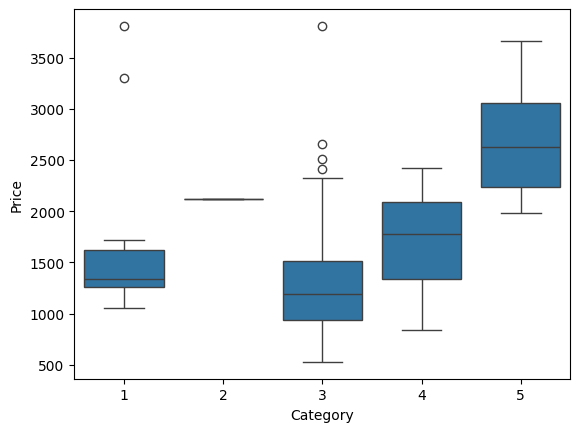

In [ ]:
# As shown there a significant overlap in the distribution, so Category is not a good predictor of price.
sns.boxplot(x='Category',y='Price', data=df)

<Axes: xlabel='GPU', ylabel='Price'>

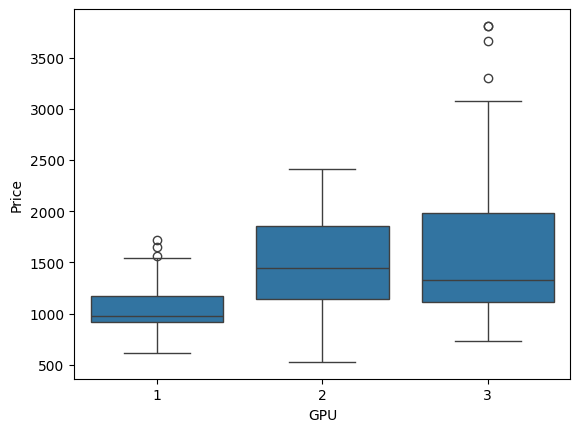

In [ ]:
# As shown there a significant overlap in the distribution, so GPU > 1 is not a good predictor of price.
sns.boxplot(x='GPU',y='Price', data=df)

<Axes: xlabel='OS', ylabel='Price'>

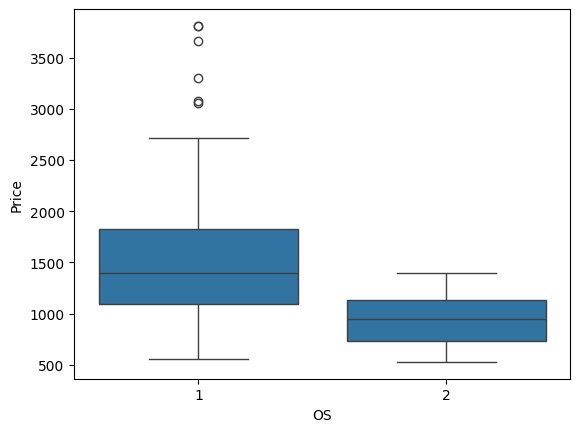

In [ ]:
# As shown there is no overlap in the distribution, so OS is a good predictor of price.
sns.boxplot(x='OS',y='Price', data=df)

<Axes: xlabel='CPU_core', ylabel='Price'>

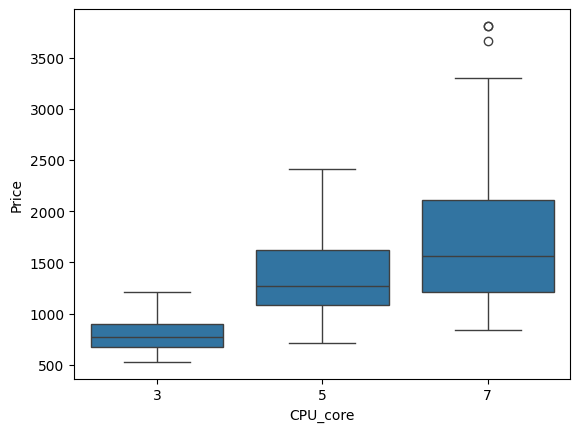

In [ ]:
# As shown there is some overlap in the distribution, so CPU_core is may/may not be a good predictor of price.
sns.boxplot(x='CPU_core',y='Price', data=df)

<Axes: xlabel='RAM_GB', ylabel='Price'>

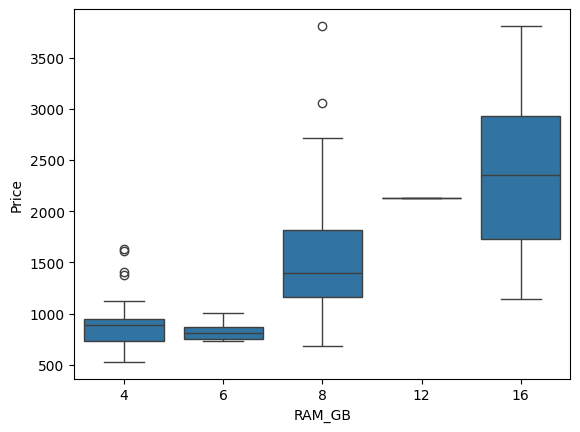

In [ ]:
# As shown there are some overlap in the distribution, so RAM_GB is may/may not be a good predictor of price.
sns.boxplot(x='RAM_GB',y='Price', data=df)

<Axes: xlabel='Storage_GB_SSD', ylabel='Price'>

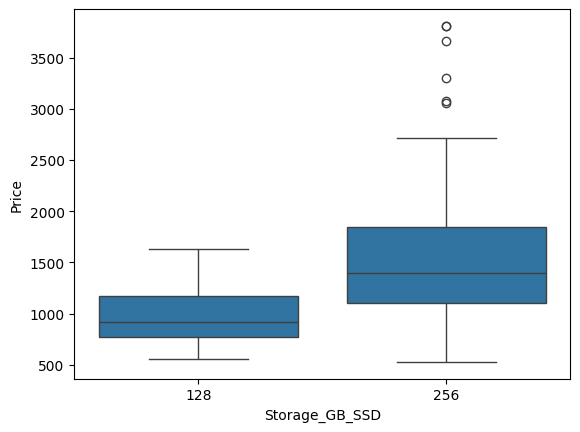

In [ ]:
# As shown there a no significant overlap in the distribution, so Storage_GB_SSD is a good predictor of price.
sns.boxplot(x='Storage_GB_SSD',y='Price', data=df)

In [21]:
# Descriptive Statistical Analysis

df.describe()


,Category,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Screen_Size_in,Weight_lb
count,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000
mean,3.205882,2.151261,1.058824,5.630252,37.307395,0.813822,7.882353,245.781513,1.862232,1462.344538,14.687951,4.106221
std,0.776533,0.638282,0.235790,1.241787,2.960595,0.141860,2.482603,34.765316,0.489090,574.607699,1.165589,1.078442
min,1.000000,1.000000,1.000000,3.000000,30.480000,0.413793,4.000000,128.000000,0.810000,527.000000,12.000000,1.786050
25%,3.000000,2.000000,1.000000,5.000000,35.560000,0.689655,8.000000,256.000000,1.472500,1066.500000,14.000000,3.246863
50%,3.000000,2.000000,1.000000,5.000000,38.100000,0.862069,8.000000,256.000000,1.862232,1333.000000,15.000000,4.106221
75%,4.000000,3.000000,1.000000,7.000000,39.620000,0.931034,8.000000,256.000000,2.200000,1777.000000,15.598425,4.851000
max,5.000000,3.000000,2.000000,7.000000,43.940000,1.000000,16.000000,256.000000,3.600000,3810.000000,17.299213,7.938000


In [22]:
df.describe(include=['object','str'])

,Manufacturer,Price-binned
count,238,238
unique,11,3
top,Dell,Low
freq,71,160


In [28]:
# GroupBy and Pivot Tables

# Group the parameters 'GPU','CPU_core', and 'Price' to make a pivot table and visualize this connection using the pcolor plot.
df_group = df[['GPU','CPU_core','Price']]

# grouping by multiple columns value
df_groupby_multi_col = df_group.groupby(['GPU','CPU_core'], as_index=False).mean()
print(df_groupby_multi_col)
df_pivot_multi_col = df_groupby_multi_col.pivot(index='GPU',columns='CPU_core').fillna(0) # better visualization in pivot table
df_pivot_multi_col

# From the pivot table, on average, a laptop with a 3 core CPU with 2 GPU is cheaper than a 5 core CPU with 1 GPU.
# The number of CPU core has more impact on the price than the number of GPU once the number of GPU is > 1.

   GPU  CPU_core        Price
0    1         3   769.250000
1    1         5   998.500000
2    1         7  1167.941176
3    2         3   785.076923
4    2         5  1462.197674
5    2         7  1744.621622
6    3         3   784.000000
7    3         5  1220.680000
8    3         7  1945.097561


Price                          
CPU_core           3            5            7
GPU                                           
1         769.250000   998.500000  1167.941176
2         785.076923  1462.197674  1744.621622
3         784.000000  1220.680000  1945.097561

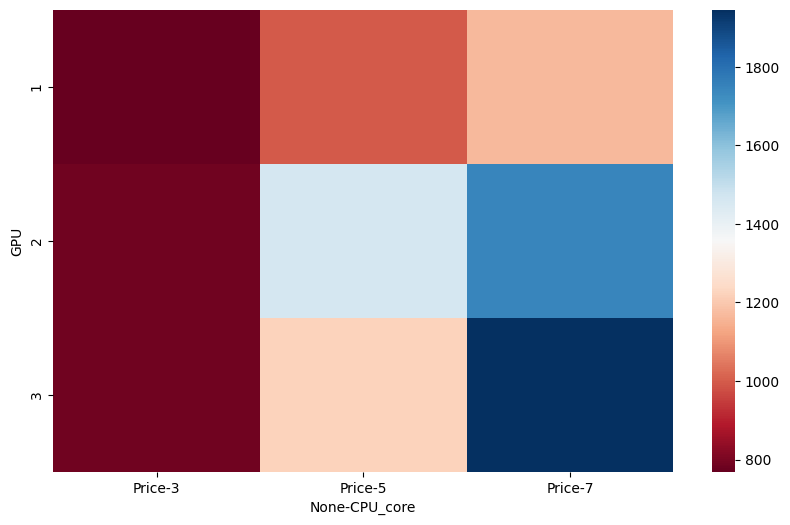

In [29]:
# heatmap - GPU, CPU_core vs price
plt.figure(figsize=(10,6))
hm = sns.heatmap(df_pivot_multi_col, cmap='RdBu')
plt.show()

In [30]:
# Pearson Correlation measures the linear dependence between two variables X and Y.

df.select_dtypes(include=['number']).corr()  # correlation only works with numeric values

,Category,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Screen_Size_in,Weight_lb
Category,1.000000,-0.114174,-0.043378,0.232425,-0.285397,-0.053414,0.030127,0.038246,-0.381032,0.286243,-0.285397,-0.381032
GPU,-0.114174,1.000000,-0.199549,0.145388,0.154366,0.291439,0.218973,0.094288,0.262853,0.288298,0.154366,0.262853
OS,-0.043378,-0.199549,1.000000,0.016954,0.146614,0.050407,-0.074625,0.007751,0.120858,-0.221730,0.146614,0.120858
CPU_core,0.232425,0.145388,0.016954,1.000000,0.041123,0.242722,0.473075,0.400015,0.068599,0.459398,0.041123,0.068599
Screen_Size_cm,-0.285397,0.154366,0.146614,0.041123,1.000000,-0.000955,0.018237,0.119746,0.797605,-0.110565,1.000000,0.797605
CPU_frequency,-0.053414,0.291439,0.050407,0.242722,-0.000955,1.000000,0.226736,0.035557,0.066522,0.366666,-0.000955,0.066522
RAM_GB,0.030127,0.218973,-0.074625,0.473075,0.018237,0.226736,1.000000,0.361469,0.055068,0.549297,0.018237,0.055068
Storage_GB_SSD,0.038246,0.094288,0.007751,0.400015,0.119746,0.035557,0.361469,1.000000,0.112519,0.243421,0.119746,0.112519
Weight_kg,-0.381032,0.262853,0.120858,0.068599,0.797605,0.066522,0.055068,0.112519,1.000000,-0.050312,0.797605,1.000000
Price,0.286243,0.288298,-0.221730,0.459398,-0.110565,0.366666,0.549297,0.243421,-0.050312,1.000000,-0.110565,-0.050312


In [34]:
# Pearson Correlation and p-value

for param in ['RAM_GB','CPU_frequency','Storage_GB_SSD','Screen_Size_cm','Weight_kg','CPU_core','OS','GPU','Category']:
    pc = stats.pearsonr(df[param],df['Price'])
    print(f"{param}:")
    print(f"\tPearson Correlation: {pc.statistic}")
    print(f"\tP-value {pc.pvalue}")
    print()

RAM_GB:
	Pearson Correlation: 0.5492972971857844
	P-value 3.6815606288428415e-20

CPU_frequency:
	Pearson Correlation: 0.36666555892588604
	P-value 5.502463350713357e-09

Storage_GB_SSD:
	Pearson Correlation: 0.243420755218103
	P-value 0.0001489892319172414

Screen_Size_cm:
	Pearson Correlation: -0.11056471275425055
	P-value 0.0887645673270076

Weight_kg:
	Pearson Correlation: -0.050312258377515434
	P-value 0.4397693853433896

CPU_core:
	Pearson Correlation: 0.4593977773355115
	P-value 7.912950127009183e-14

OS:
	Pearson Correlation: -0.22172980114827384
	P-value 0.0005696642559246719

GPU:
	Pearson Correlation: 0.2882981988881427
	P-value 6.16694969836445e-06

Category:
	Pearson Correlation: 0.28624275581264125
	P-value 7.22569623580658e-06

